In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from nba_api.stats.endpoints import leaguedashplayerstats
import pandas as pd

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 67 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              582 non-null    int64  
 1   PLAYER_NAME            582 non-null    object 
 2   NICKNAME               582 non-null    object 
 3   TEAM_ID                582 non-null    int64  
 4   TEAM_ABBREVIATION      582 non-null    object 
 5   AGE                    582 non-null    float64
 6   GP                     582 non-null    int64  
 7   W                      582 non-null    int64  
 8   L                      582 non-null    int64  
 9   W_PCT                  582 non-null    float64
 10  MIN                    582 non-null    float64
 11  FGM                    582 non-null    int64  
 12  FGA                    582 non-null    int64  
 13  FG_PCT                 582 non-null    float64
 14  FG3M                   582 non-null    int64  
 15  FG3A  

In [ ]:
# Filter: Remove players with very few games played to avoid outliers
df_filtered = df[df['GP'] > 10].copy()

print(f"Original players: {len(df)}, After filtering: {len(df_filtered)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 67 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   PLAYER_ID              582 non-null    int64  
 1   PLAYER_NAME            582 non-null    object 
 2   NICKNAME               582 non-null    object 
 3   TEAM_ID                582 non-null    int64  
 4   TEAM_ABBREVIATION      582 non-null    object 
 5   AGE                    582 non-null    float64
 6   GP                     582 non-null    int64  
 7   W                      582 non-null    int64  
 8   L                      582 non-null    int64  
 9   W_PCT                  582 non-null    float64
 10  MIN                    582 non-null    float64
 11  FGM                    582 non-null    int64  
 12  FGA                    582 non-null    int64  
 13  FG_PCT                 582 non-null    float64
 14  FG3M                   582 non-null    int64  
 15  FG3A  

### Distribution of Key Metrics
We want to see how points and minutes are distributed across the league. 

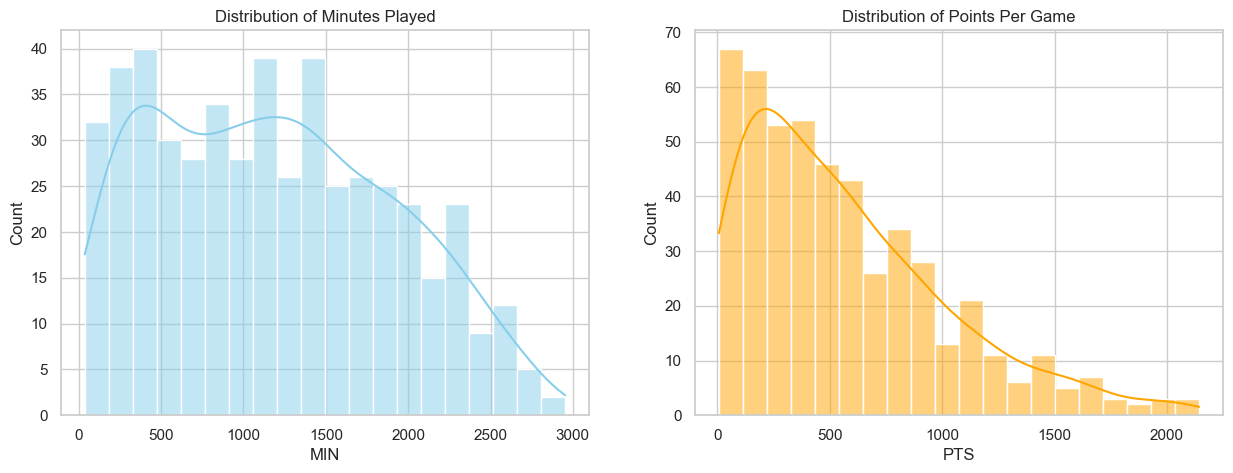

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Minutes distribution
sns.histplot(df_filtered['MIN'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Minutes Played')

# Points distribution
sns.histplot(df_filtered['PTS'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Points Per Game')

plt.show()

- Points Per Game: most players score a relatively low amount of total points over a season. The tail extending to the right represents the elite scores, suggesting a small percentage of players are responsible for a large percentage of the league's total points. 

### Offensive Efficiency: Volume vs. Accuracy
The more shots you take, the harder it is to keep a high percentage of accuracy. 

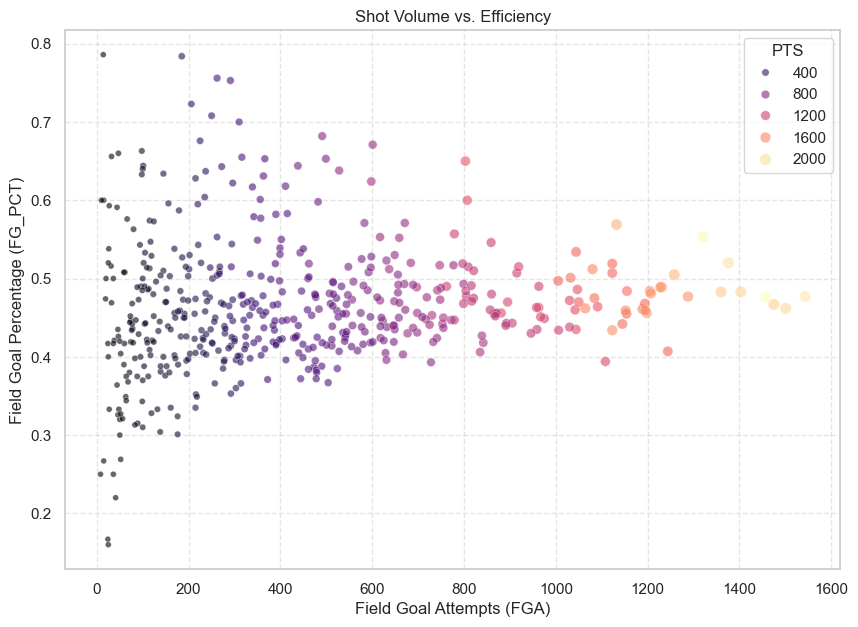

In [34]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_filtered, x='FGA', y='FG_PCT', hue='PTS', size='PTS', alpha=0.6, palette='magma')

plt.title('Shot Volume vs. Efficiency')
plt.xlabel('Field Goal Attempts (FGA)')
plt.ylabel('Field Goal Percentage (FG_PCT)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- Funnel Effect: As FGA increases, the dots converge toward a 45-50% range. This is because taking 1200+ shots a season usually means you are the focal point of the defense, maintaing a 60% completion rate at that volume is nearly impossible. 
- The yellow and organe dots on the right represent the primary scorers. Those who are higher up on the Y-axis at the high volume are the most elite. 
- The dark purple dots at the top left are likely centers who only take high-percentage dunks and layups.

### Team Profile

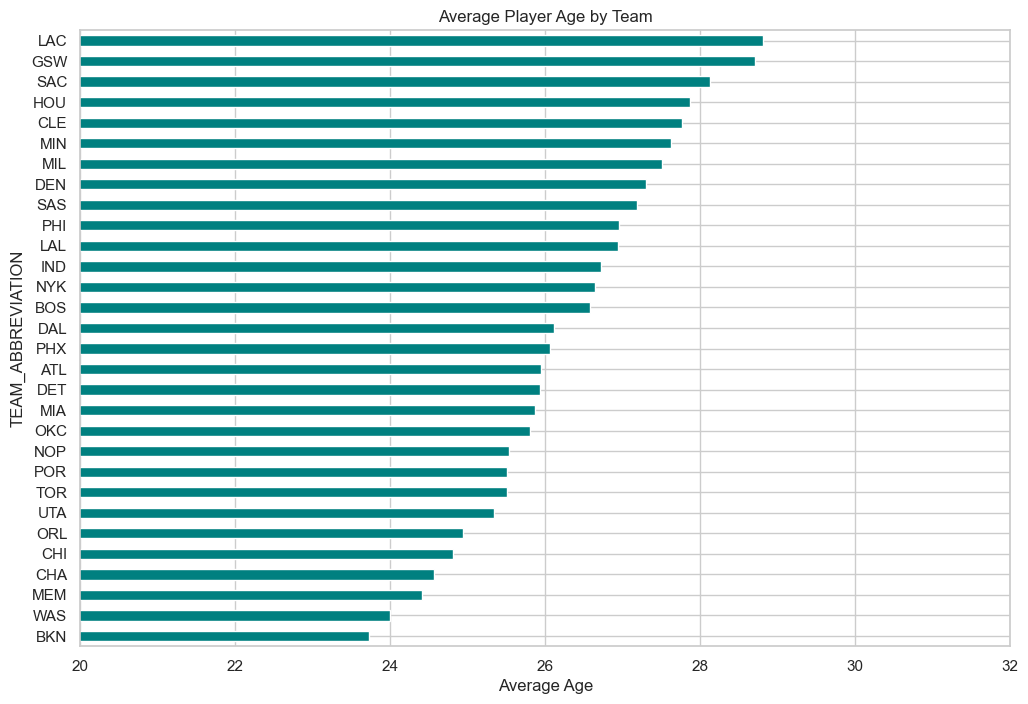

In [37]:
# Group by team and calculate the average age
team_age = df_filtered.groupby('TEAM_ABBREVIATION')['AGE'].mean().sort_values()

plt.figure(figsize=(12, 8))
team_age.plot(kind='barh', color='teal')
plt.title('Average Player Age by Team')
plt.xlabel('Average Age')
plt.xlim(20, 32) # Zoom in on the relevant age range
plt.show()

### "Unicorns"
Find players elite in two unrelated categories (eg. Assists(AST) and Blocks(BLK)). Players high in both are "unicorns".

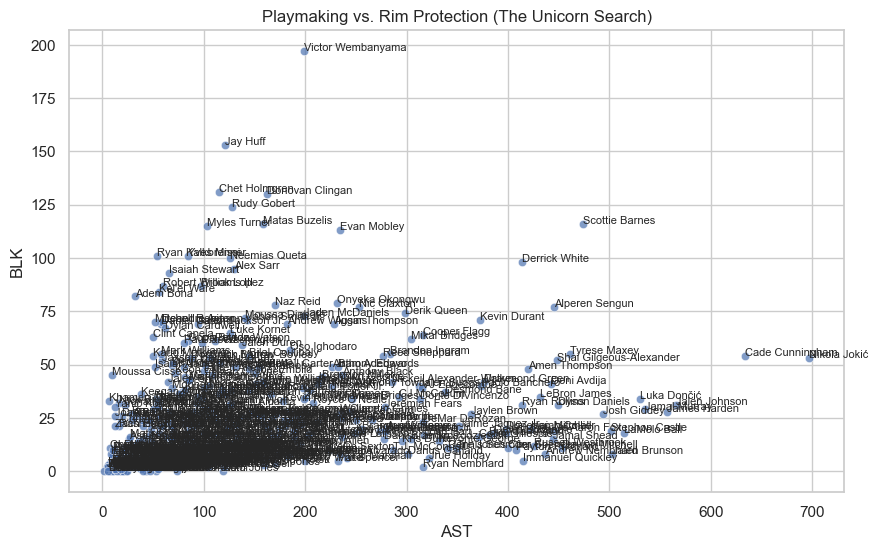

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='AST', y='BLK', alpha=0.7)

# Labeling outliers (the Unicorns)
outliers = df_filtered[(df_filtered['AST'] > 5) | (df_filtered['BLK'] > 1.5)]
for i, txt in enumerate(outliers['PLAYER_NAME']):
    plt.annotate(txt, (outliers['AST'].iloc[i], outliers['BLK'].iloc[i]), fontsize=8)

plt.title('Playmaking vs. Rim Protection (The Unicorn Search)')
plt.show()

- Bottom right (high AST, low BLK): These elite floor generals like Nikola Jokic, Luka Doncic, who control the offense but aren't primary rim protectors.
- Top left (low AST, high BLK): These are traditional paint protectors like Rudy Gobert and Walker Kessler. 
- Unicorn: Victor Wembanyama is the massive outlier at the top. Even with moderate assists, his shot-blocking total is notably higher than others.
- All-round stars: Players in the middle-right/top like Scottie Barners and Giannis Antetokounmpo contribute significatnly in both playmaking and defense. 

### Team Scoring Concentration
See if certain teams rely on one superstar (large spread with outliers) or if they have a balanced scoring. 

/var/folders/0l/nv2w_zqn0rncbhxnnml3xmdw0000gn/T/ipykernel_88166/2522273974.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_teams, x='TEAM_ABBREVIATION', y='PTS', palette='Set3')


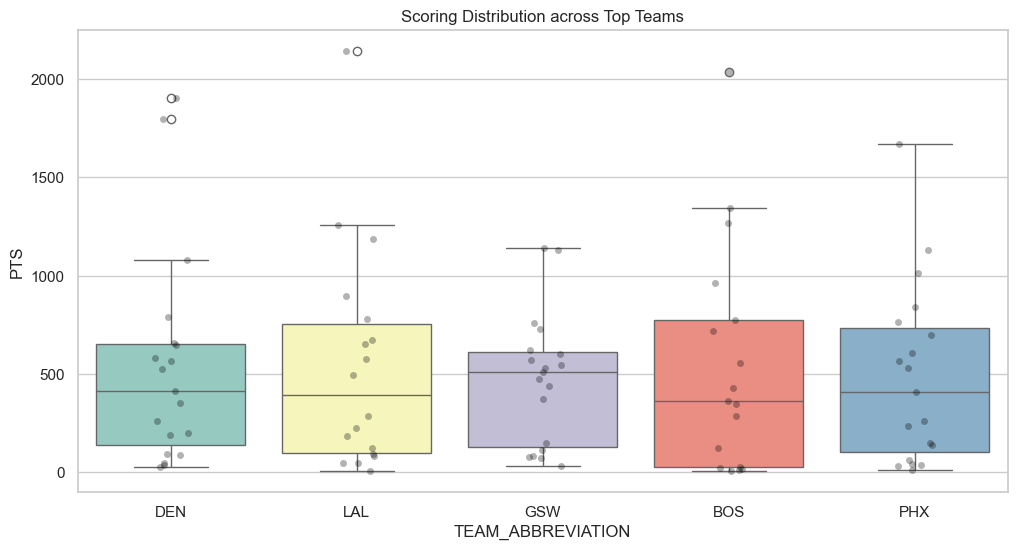

In [42]:
# Select a few interesting teams to compare
target_teams = ['BOS', 'LAL', 'GSW', 'DEN', 'PHX']
df_teams = df[df['TEAM_ABBREVIATION'].isin(target_teams)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_teams, x='TEAM_ABBREVIATION', y='PTS', palette='Set3')
sns.stripplot(data=df_teams, x='TEAM_ABBREVIATION', y='PTS', color='black', alpha=0.3) # Overlay individual players
plt.title('Scoring Distribution across Top Teams')
plt.show()

- Outliers: There are individual dots far above the boxes for DEN (Denver), LAL (Lakers), BOS(Boston). These represent players like Jokic, LeBron, and Tatum. 
- PHX: The top line is very high, suggesting their top scorers are extremely productive, but thier box is also relatively compact, showing a specific middle-class of scorers.

### Usage and Efficiency Trade-off
As a player's usage (the number of possessions they end) increases, their efficiency (FG%) typically decrease because they have to take more difficult, contested shots.

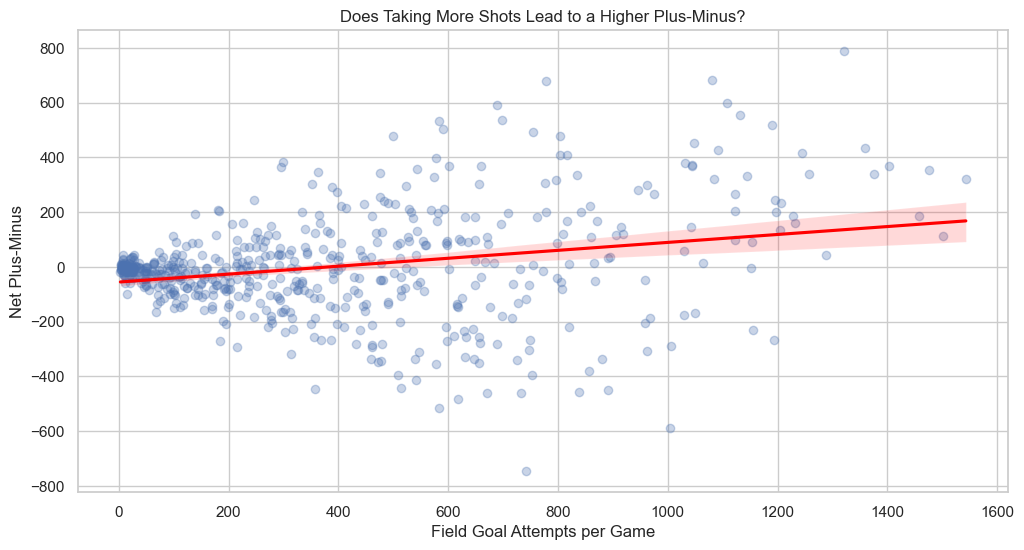

In [43]:
plt.figure(figsize=(12, 6))
sns.regplot(data=df[df['MIN'] > 15], x='FGA', y='PLUS_MINUS', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Does Taking More Shots Lead to a Higher Plus-Minus?')
plt.xlabel('Field Goal Attempts per Game')
plt.ylabel('Net Plus-Minus')
plt.show()

- There is a positive correlation between FGA and PLUS_MINUS, meaning players who take more shoots generally have a higher impact on the game's outcome.
- The dots spread out more as move to the right. This means while high-volume shooters can have a massive positive impact, they also carry a higher risk of being deeply negative if they have a bad shooting night. 

### Correlation Heatmap of Defensive Metrics

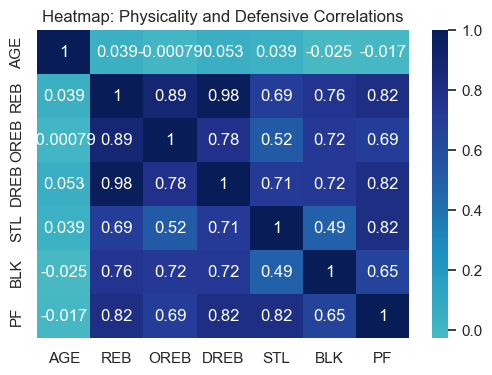

In [46]:
# Focus on defensive and physical variables
defensive_cols = ['AGE', 'REB', 'OREB', 'DREB', 'STL', 'BLK', 'PF']
corr = df[defensive_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='YlGnBu', center=0)
plt.title('Heatmap: Physicality and Defensive Correlations')
plt.show()

- There is a high correlation between REB and BLK (0.76), as well as between REB and PF (0.82). These players get rebounds and blocks, but because they are defending the rim, they also rack up the most fouls. 
- The AGE row almost have 0 correlation with defensive stats. This means defensive hustle doesn't decline or improve drastically because a player gets older. 